In [28]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from pydantic import BaseModel
from langchain_groq import ChatGroq
from dotenv import load_dotenv


In [29]:
load_dotenv()

True

In [30]:
llm = ChatGroq(model="llama-3.1-8b-instant")

In [31]:
reviewDecision = Literal['approved', 'rewrite']
class WorkflowState(TypedDict):
    userInput: str
    draft: str
    reviewDecision: reviewDecision
    output: str

class DraftReviewOut(BaseModel):
    reviewDecision: reviewDecision


In [32]:
def emailWriter(state: WorkflowState) -> WorkflowState:
    prompt = f"""You are a helpful assistant that drafts emails based on user requests. Here is the user request: {state['userInput']}"""
    response = llm.invoke(prompt)

    state["draft"] = response.content
    return state

In [33]:
def reviewDraft(state: WorkflowState) -> WorkflowState:
    prompt = f"""You are a helpful assistant that reviews email drafts. Here is the draft: {state['draft']}. Please decide if the draft is good or if it needs to be rewritten."""
    reviewer = llm.with_structured_output(DraftReviewOut)
    response = reviewer.invoke(prompt)
    state["reviewDecision"] = response.reviewDecision
    return state

def rewriteDraft(state: WorkflowState) -> WorkflowState:
    prompt = f"""You are a helpful assistant that rewrites email drafts. Here is the draft that needs to be rewritten: {state['draft']}"""
    response = llm.invoke(prompt)
    state["draft"] = response.content
    return state

In [34]:
def routeTask(state: WorkflowState):
    if state["reviewDecision"] == "approved":
        return END
    elif state["reviewDecision"] == "rewrite":
        return "rewriteDraft"

In [35]:
graph = StateGraph(WorkflowState)

graph.add_node("emailWriter", emailWriter)
graph.add_node("reviewDraft", reviewDraft)
graph.add_node("rewriteDraft", rewriteDraft)

graph.add_edge(START, "emailWriter")
graph.add_edge("emailWriter", "reviewDraft")
graph.add_conditional_edges("reviewDraft", routeTask)
graph.add_edge("rewriteDraft", END)

workflow = graph.compile()


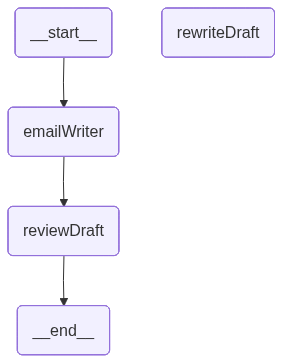

In [36]:
workflow

In [37]:
test_state = {"userInput": "Please draft an email to the marketing team about the new product launch.",
              "draft": "",
              "reviewDecision": "",
              "output": ""}

result = emailWriter(test_state)
print(result["draft"])

Here's a draft email to the marketing team about the new product launch:

Subject: Exciting News: New Product Launch Imminent

Dear Marketing Team,

I hope this email finds you well. As you know, our new product has been in development for several months, and we're now just a few weeks away from its highly anticipated launch. I wanted to reach out to the team to discuss the final preparations and ensure we're all on the same page.

**Key Launch Details:**

* Launch Date: [Insert Date]
* Product Name: [Insert Product Name]
* Target Audience: [Insert Target Audience]
* Marketing Channels: [Insert Marketing Channels, e.g., Social Media, Email, Influencer Marketing, etc.]
* Promotional Offers: [Insert Promotional Offers, e.g., Discounts, Free Shipping, etc.]

**Next Steps:**

* Finalize all marketing materials, including social media assets, email templates, and influencer partnerships.
* Coordinate with the sales team to ensure a smooth product rollout and adequate inventory levels.
* Rev

In [38]:
result = workflow.invoke(test_state)

In [ ]:
print(result["draft"])